In [1]:
import pandas as pd
# Load all seasons
seasons = [
    "21-22.csv",
    "22-23.csv",
    "23-24.csv",
    "24-25.csv",
    "25-26.csv"
]

dfs = []

for season in seasons:
    df = pd.read_csv(f"dataset/{season}")
    df['Season'] = season[:5]
    dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)

===== TOP 10 FEATURES =====
                             Feature  Importance
            num__Shots_Rolling10_all    0.020186
                   num__TablePosDiff    0.019555
           num__Home_Shots_Rolling10    0.019349
    num__Home_TablePosDiff_Rolling10    0.018727
num__Home_TablePosDiff_Rolling10_all    0.018417
              num__Home_TablePosDiff    0.017999
            num__Home_Shots_Rolling5    0.017833
 num__Home_TablePosDiff_Rolling5_all    0.017549
                num__Shots_Rolling10    0.017416
   num__Home_ShotsOnTarget_Rolling10    0.017400

===== BOTTOM 10 FEATURES =====
                       Feature  Importance
         cat__HomeTeam_Ipswich    0.000319
         cat__HomeTeam_Watford    0.000310
         cat__AwayTeam_Ipswich    0.000271
         cat__AwayTeam_Watford    0.000256
           cat__AwayTeam_Luton    0.000235
         cat__AwayTeam_Norwich    0.000230
cat__HomeTeam_Sheffield United    0.000192
           cat__HomeTeam_Luton    0.000190
cat__AwayTeam_

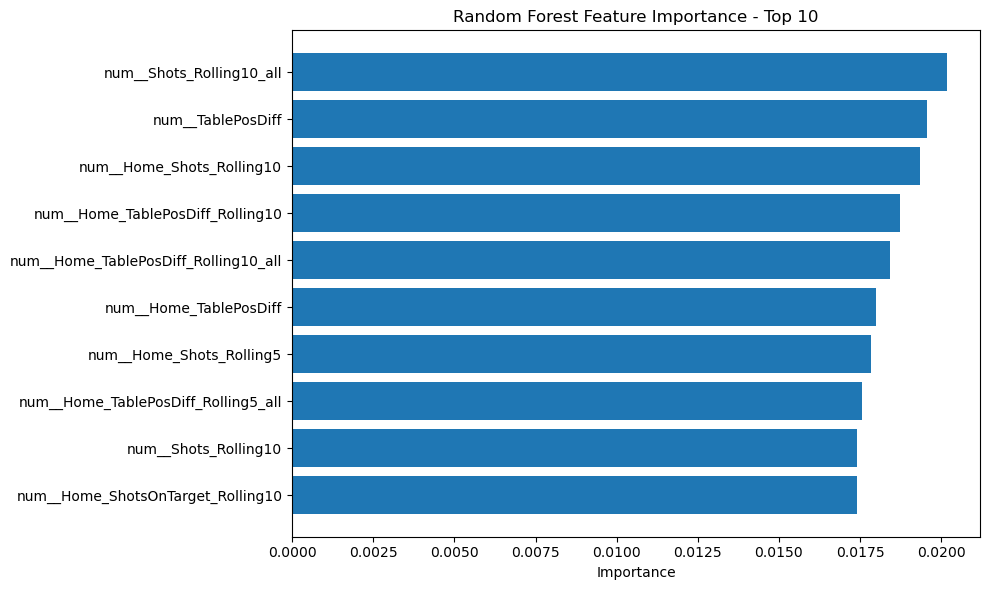

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# CREATE X AND Y
# -----------------------------

y = all_df["FTR"]


X = all_df.drop(
    columns=[
        "Date",
        "Time",
        "FTR",
        "FTHG",
        "FTAG"
    ]
)

# -----------------------------
# TIME SPLIT
# -----------------------------

split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]


# -----------------------------
# ENCODE TARGET
# -----------------------------

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)


# -----------------------------
# PREPROCESS FEATURES
# -----------------------------

categorical = [
    "HomeTeam",
    "AwayTeam",
    "Season"
]


numerical = [
    c for c in X_train.columns
    if c not in categorical
]


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical
        )
    ]
)


X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)


# -----------------------------
# RANDOM FOREST
# -----------------------------

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(
    X_train_processed,
    y_train
)


# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------

feature_names = (
    preprocessor
    .get_feature_names_out()
)


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})


importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)


print("===== TOP 10 FEATURES =====")
print(
    importance_df.head(10).to_string(index=False)
)


print("\n===== BOTTOM 10 FEATURES =====")
print(
    importance_df.tail(10).to_string(index=False)
)


# -----------------------------
# PLOT TOP 10
# -----------------------------

top10 = (
    importance_df
    .head(10)
    .sort_values("Importance")
)


plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.xlabel("Importance")
plt.title(
    "Random Forest Feature Importance - Top 10"
)

plt.tight_layout()
plt.show()